In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from pathlib import Path
from IPython.display import HTML

In [11]:
base_dir = "./outputs/NN_Files_9_denormalized_data/"

output_dir = f"{base_dir}animation"
layout_dir = Path(f"{base_dir}Python_Layout")

# Find total number of layout files
n_layouts = len(list(layout_dir.glob("Layout_*.txt")))
print(f"Found {n_layouts} layout files")

Found 150 layout files


- 200k events are used to train the ReconstructionNN
- loop
    - ReconstructionNN used to reconstruct primary features form secondary events, based on minibatches (500) 
    - This reconstruction updates the location of the detectors got 5 epochs
    - every 5 epochs finetune the ReconstructionNN, with 5k samples

# Layout start / end

Plotting: Layout_450.txt


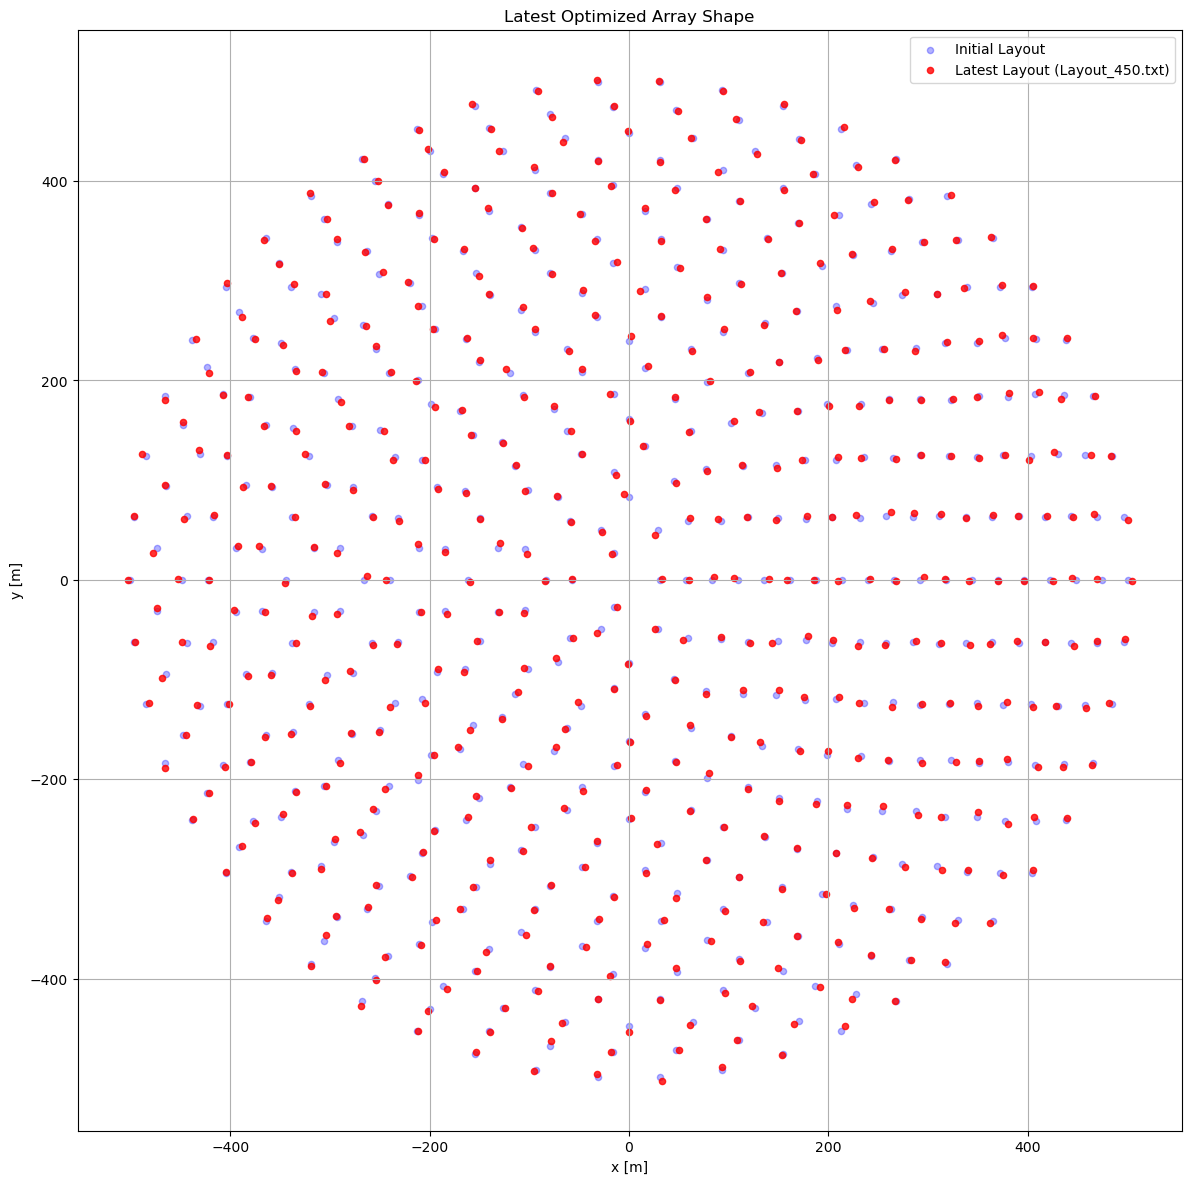

In [14]:
import numpy as np
import matplotlib.pyplot as plt

output_dir = "./outputs/NN_Files_9_denormalized_data"

# Find the latest layout file
from pathlib import Path
layout_files = sorted(Path(f"{output_dir}/Python_Layout").glob("Layout_*.txt"),
                      key=lambda p: int(p.stem.split("_")[1]))
latest = layout_files[-1]
print(f"Plotting: {latest.name}")

data = np.loadtxt(latest)
x_latest = data[:, 0]
y_latest = data[:, 1]

# Initial layout for comparison
n_rings = 20
R = np.linspace(5, 500, n_rings)
weights = R / R.sum()
N = np.round(weights * 500).astype(int)
N[-1] += 500 - N.sum()
radii = np.repeat(R, N)
angles = np.concatenate([np.linspace(0, 2 * np.pi, n, endpoint=False) for n in N])
x_init = radii * np.cos(angles)
y_init = radii * np.sin(angles)

fig, ax = plt.subplots(figsize=(12, 12))
ax.scatter(x_init, y_init, color="blue", alpha=0.3, label="Initial Layout", s=20)
ax.scatter(x_latest, y_latest, color="red", alpha=0.8, label=f"Latest Layout ({latest.name})", s=20)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Latest Optimized Array Shape")
ax.set_aspect("equal")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

## Layout Evolution Video

In [19]:
n_layouts

150

In [21]:
# Preload all layouts into memory (much faster than reading per frame)
step = 5  # use every 5th layout to reduce frame count
frame_indices = list(range(301, 300+n_layouts, step))
layouts = []
for i in frame_indices:
    data = np.loadtxt(layout_dir / f"Layout_{i + 1}.txt")
    layouts.append(data)
print(f"Loaded {len(layouts)} frames (every {step}th layout)")

Loaded 30 frames (every 5th layout)


In [22]:
%%capture
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-750, 750)
ax.set_ylim(-750, 750)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")
ax.grid(True)
scatter = ax.scatter([], [], color="red", s=5)
title = ax.set_title("")

def init():
    scatter.set_offsets(np.empty((0, 2)))
    title.set_text("")
    return scatter, title

def update(frame):
    scatter.set_offsets(layouts[frame])
    title.set_text(f"Layout Step {frame_indices[frame] + 1}/{n_layouts}")
    return scatter, title

anim = animation.FuncAnimation(fig, update, init_func=init,
                                frames=len(layouts), interval=100, blit=True)

In [23]:
# Save as GIF (no ffmpeg needed) and display inline
gif_path = Path(output_dir) / "layout_evolution.gif"
gif_path.parent.mkdir(parents=True, exist_ok=True)
anim.save(str(gif_path), writer="pillow", fps=10, dpi=80)
plt.close(fig)
print(f"Video saved to {gif_path}")

HTML(anim.to_jshtml())

Video saved to outputs/NN_Files_9_denormalized_data/layout_evolution.gif


## Utility: Scatter Plot + 7-Step Running Average

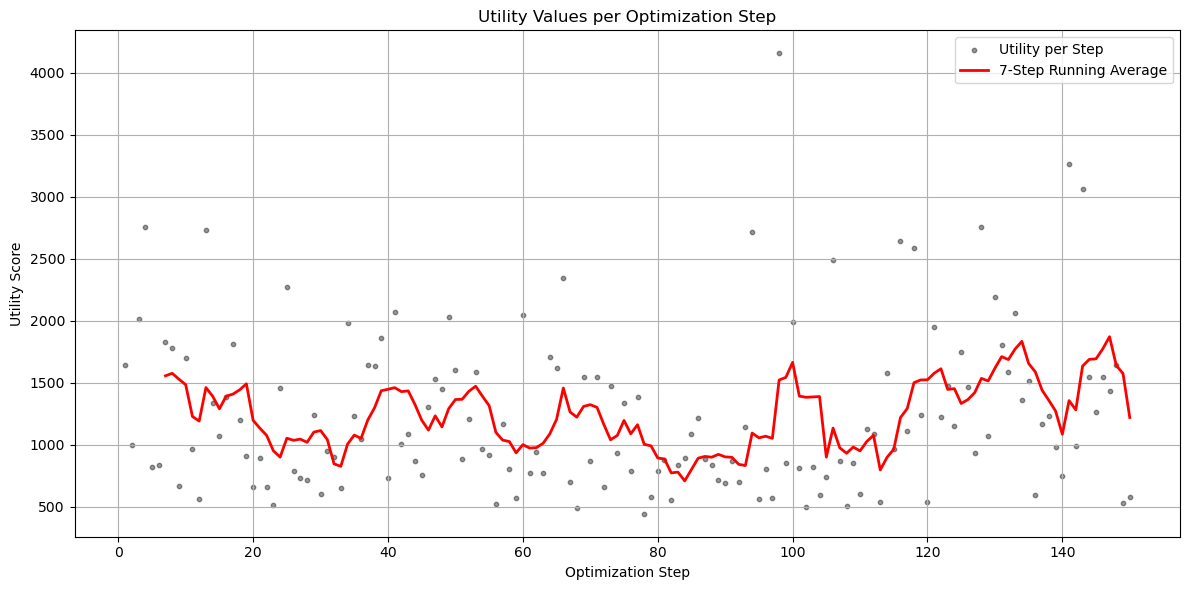

In [24]:
# Load utility values
utilities = np.loadtxt(layout_dir / "Utilities.txt")
epochs = np.arange(1, len(utilities) + 1)

# 7-step running average
window = 7
mean_util = np.convolve(utilities, np.ones(window) / window, mode="valid")
mean_epochs = np.arange(window, len(utilities) + 1)

plt.figure(figsize=(12, 6))
plt.scatter(epochs, utilities, color="black", s=10, alpha=0.4, label="Utility per Step")
plt.plot(mean_epochs, mean_util, color="red", linewidth=2, label=f"{window}-Step Running Average")
plt.xlabel("Optimization Step")
plt.ylabel("Utility Score")
plt.title("Utility Values per Optimization Step")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()